In [3]:
"""
CodeAlpha Internship - Task 1: Credit Scoring Model using Machine Learning
BY - Abhishek Madhav
Description :- Developed a Machine Learning-based Credit Scoring Model to predict customer creditworthiness using financial data.
"""

'\nCodeAlpha Internship - Task 1: Credit Scoring Model using Machine Learning\nBY - Abhishek Madhav\nDescription :- Developed a Machine Learning-based Credit Scoring Model to predict customer creditworthiness using financial data.\n'

In [9]:
from google.colab import files
uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data.csv


In [11]:
import pandas as pd

df = pd.read_csv('german_credit_data.csv')

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [38]:
# df = pd.read_csv('german_credit_data.csv') # Commented out to prevent re-loading data and overwriting encoding

In [26]:
print(df.isnull().sum())

status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64


In [27]:
print(df.head())

        status_account  month_duration  \
0               < 0 DM               6   
1        0 to < 200 DM              48   
2  no checking account              12   
3               < 0 DM              42   
4               < 0 DM              24   

                                      credit_history              purpose  \
0  critical account/ other credits existing (not ...     radio/television   
1           existing credits paid back duly till now     radio/television   
2  critical account/ other credits existing (not ...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   credit_amount               status_savings years_employment  \
0           1169  unknown/ no savings account       >= 7 years   
1           5951                     < 100 DM   1 to < 4 years   
2           2096                     < 100 DM   4 to < 7 years   
3           7882    

In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [18]:
df.fillna(0, inplace=True)

In [19]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))


In [32]:
X = df.drop('target', axis=1)
y = df['target']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
# Re-apply Label Encoding and re-split data to ensure all features are numerical
from sklearn.preprocessing import LabelEncoder

# Re-initialize LabelEncoder to avoid state issues from previous runs
le = LabelEncoder()

# Identify object columns in the current df state and apply LabelEncoder
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Re-define X and y with the fully encoded DataFrame
X = df.drop('target', axis=1)
y = df['target']

# Re-split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data successfully re-encoded and split.")
print("X_train dtypes after re-encoding:")
print(X_train.dtypes)


Data successfully re-encoded and split.
X_train dtypes after re-encoding:
status_account             int64
month_duration             int64
credit_history             int64
purpose                    int64
credit_amount              int64
status_savings             int64
years_employment           int64
payment_to_income_ratio    int64
status_and_sex             int64
secondary_obligor          int64
residence_since            int64
collateral                 int64
age                        int64
other_installment_plans    int64
housing                    int64
n_credits                  int64
job                        int64
n_guarantors               int64
telephone                  int64
is_foreign_worker          int64
dtype: object


In [43]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [44]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [45]:
def evaluate_model(y_test, predictions, model_name):

    print(f"\n===== {model_name} =====")

    print("Accuracy :", accuracy_score(y_test, predictions))
    print("Precision:", precision_score(y_test, predictions))
    print("Recall   :", recall_score(y_test, predictions))
    print("F1 Score :", f1_score(y_test, predictions))

    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, predictions))


In [46]:
evaluate_model(y_test, lr_pred, "Logistic Regression")

evaluate_model(y_test, dt_pred, "Decision Tree")

evaluate_model(y_test, rf_pred, "Random Forest")


===== Logistic Regression =====
Accuracy : 0.72
Precision: 0.7514792899408284
Recall   : 0.900709219858156
F1 Score : 0.8193548387096774

Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.29      0.38        59
           1       0.75      0.90      0.82       141

    accuracy                           0.72       200
   macro avg       0.65      0.59      0.60       200
weighted avg       0.69      0.72      0.69       200


Confusion Matrix:

[[ 17  42]
 [ 14 127]]

===== Decision Tree =====
Accuracy : 0.71
Precision: 0.7785234899328859
Recall   : 0.8226950354609929
F1 Score : 0.8

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.44      0.47        59
           1       0.78      0.82      0.80       141

    accuracy                           0.71       200
   macro avg       0.64      0.63      0.64       200
weighted avg       0.70      0.71      0.70       20

In [47]:
importance = rf.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")
print(feature_df)



Feature Importance:

                    Feature  Importance
4             credit_amount    0.132465
12                      age    0.108433
0            status_account    0.107271
1            month_duration    0.094339
3                   purpose    0.069329
2            credit_history    0.059104
6          years_employment    0.050732
11               collateral    0.048576
5            status_savings    0.044027
7   payment_to_income_ratio    0.042691
10          residence_since    0.042348
8            status_and_sex    0.034354
16                      job    0.032561
13  other_installment_plans    0.028692
14                  housing    0.027740
15                n_credits    0.022649
18                telephone    0.021166
9         secondary_obligor    0.017360
17             n_guarantors    0.012431
19        is_foreign_worker    0.003733


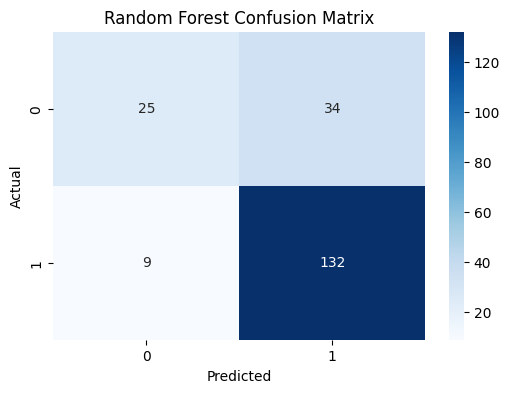

In [48]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [49]:
final_accuracy = accuracy_score(y_test, rf_pred)

print("\nFinal Random Forest Accuracy:", final_accuracy)


Final Random Forest Accuracy: 0.785
